# <p style="font-size:100%; text-align:left; color:#444444;">H5N1 strain of avian flu - Wild Bird Species Identification</p>

<img src='./img/wild-geese-pixabay_1149609_1920.jpeg' style='height:400px; border-radius: 5px;'/>

---
# <p style="font-size:100%; text-align:left; color:#444444;">Contents:</p>

* [1. Introduction](#1)
    * [1.1 Data Description](#1.1)
    * [1.2 Libraries](#1.2)
    * [1.3 Loading Dataset](#1.3)
* [2. Preprocessing & Feature Engineering](#2)
    * [2.1 Target variable distribution](#2.1)
    * [2.2 Missing values](#2.2)
    * [2.3 Exploratory Analysis](#2.3)
    * [2.4 Features Importance](#2.4)
    * [2.5 Data transformation and normalization](#2.5)
* [3. Models](#3)
    * [3.1 LightGBM](#3.1)
    * [3.2 XGBoost](#3.2)
    * [3.3 Random Search for Hyper-Parameter Optimization](#3.3)
    * [3.4 LightGBM Tuned](#3.4)
* [4. Evaluation](#4)
    * [4.1 Normalized Gini Coefficient](#4.1)
    * [4.2 LightGBM Evaluation](#4.2)
    * [4.3 XGBoost Evaluation](#4.3)
    * [4.4 LightGBM Tuned Evaluation](#4.4)
    * [4.5 ROC AUC](#4.5)
* [5. Conclusion](#5)

<a id="1"></a>
# <p style="font-size:100%; text-align:left; color:#444444;">1- Introduction</p>

Avian influenza or **"Bird Flu"** is a contagious and often fatal viral disease of birds. Wild birds, particularly wild migratory water birds are considered to be the main reservoir of avian influenza viruses. There is a constant risk of avian influenza being introduced into Ireland from wild birds particularly from November onwards each year as this is when migratory birds arrive and congregate on wetlands, mixing with resident species. The attached file is a data set of the locations of bird species captured in Ireland from 1980 to 2020 and wild birds that are targeted for the H5N1 strain of avian flu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
import random
import json
from pathlib import Path

%matplotlib inline
matplotlib.style.use("ggplot")

# Preprocessing
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

# Models
import lightgbm as lgb
from lightgbm import LGBMClassifier
import xgboost as xgb
from xgboost import XGBClassifier
import joblib
from numpy import savetxt
from numpy import loadtxt

# Evaluation
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc
from sklearn.metrics import roc_curve
from numpy import argmax

# Hyperparameter optimization
from sklearn.model_selection import RandomizedSearchCV

import time
import warnings
warnings.simplefilter('ignore', FutureWarning)

In [2]:
from platform import python_version
print('Python version:', python_version())

Python version: 3.8.5


In [3]:
%reload_ext watermark
%watermark -a "Leandro Pessini" --iversions

Author: Leandro Pessini

lightgbm  : 3.1.1
xgboost   : 1.4.1
json      : 2.0.9
numpy     : 1.19.2
matplotlib: 3.3.2
pandas    : 1.1.3
sys       : 3.8.5 (default, Sep  4 2020, 02:22:02) 
[Clang 10.0.0 ]
seaborn   : 0.11.1
joblib    : 1.0.1
sklearn   : 0.23.2



In [4]:
bird_flu = pd.read_csv("bird-flu.csv", encoding='latin-1')

In [5]:
bird_flu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16304 entries, 0 to 16303
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Scientific_Name       16304 non-null  object 
 1   Common_Name           16304 non-null  object 
 2   Date                  16304 non-null  object 
 3   Year                  16304 non-null  int64  
 4   Month                 16304 non-null  int64  
 5   Day                   16304 non-null  int64  
 6   Time                  16304 non-null  int64  
 7   Country               16304 non-null  object 
 8   Country_State_County  16304 non-null  object 
 9   State                 16304 non-null  object 
 10  County                16175 non-null  object 
 11  Locality              16304 non-null  object 
 12  Latitude              16304 non-null  float64
 13  Longitude             16304 non-null  float64
 14  Parent_Species        16304 non-null  object 
 15  target_H5_HPAI     

In [6]:
bird_flu.head()

,Scientific_Name,Common_Name,Date,Year,Month,Day,Time,Country,Country_State_County,State,County,Locality,Latitude,Longitude,Parent_Species,target_H5_HPAI
0,Acrocephalus scirpaceus,Eurasian Reed Warbler,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Acrocephalus scirpaceus,0
1,Acrocephalus scirpaceus,Eurasian Reed Warbler,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Acrocephalus scirpaceus,0
2,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0
3,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0
4,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0


In [7]:
pd.DataFrame({'count' : bird_flu.groupby(['Country'])['Country'].size()}).reset_index()

,Country,count
0,Ireland,16304


In [8]:
pd.DataFrame({'count' : bird_flu.groupby(['Scientific_Name'])['Scientific_Name'].size()}).reset_index()

,Scientific_Name,count
0,Acanthis cabaret,39
1,Acanthis flammea rostrata/islandica,5
2,Accipiter nisus,142
3,Acrocephalus agricola,1
4,Acrocephalus dumetorum,6
...,...,...
405,Vanellus vanellus,76
406,Vireo olivaceus,33
407,Xema sabini,31
408,Xenus cinereus,4


In [9]:
pd.DataFrame({'count' : bird_flu.groupby(['Common_Name'])['Common_Name'].size()}).reset_index()

,Common_Name,count
0,American Bittern,10
1,American Black Duck,2
2,American Coot,9
3,American Coot (Red-shielded),2
4,American Golden-Plover,51
...,...,...
405,passerine sp.,18
406,pipit sp.,4
407,swan sp.,5
408,thrush sp.,1


In [10]:
pd.DataFrame({'count' : bird_flu.groupby(['Parent_Species'])['Parent_Species'].size()}).reset_index()

,Parent_Species,count
0,Acanthis cabaret,39
1,Acanthis flammea,5
2,Accipiter nisus,142
3,Acrocephalus agricola,1
4,Acrocephalus dumetorum,6
...,...,...
333,Vanellus vanellus,76
334,Vireo olivaceus,33
335,Xema sabini,31
336,Xenus cinereus,4


In [11]:
pd.DataFrame({'count' : bird_flu.groupby(['Locality'])['Locality'].size()}).reset_index()

,Locality,count
0,"(51.5753,-9.0207)",7
1,"(51.6537,-8.9579)",2
2,"(51.8340,-8.2860)",9
3,"(51.8376,-8.2912)",2
4,"(51.9565,-7.8688) - 10 The Green",18
...,...,...
1283,route to Cruchon Mountain,1
1284,sean walsh park,1
1285,the Farm,1
1286,walk to Bull Island,4


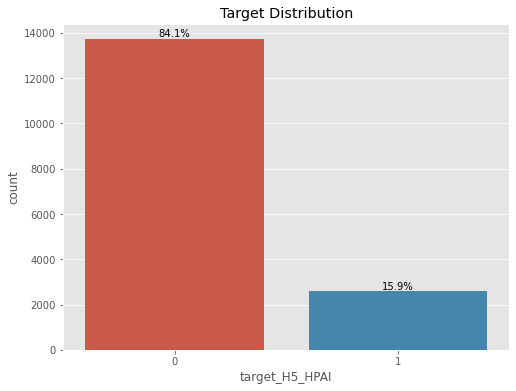

In [12]:

y = bird_flu.target_H5_HPAI
fig = plt.figure(figsize=(8, 6))
ax = sns.countplot(y,label="Count")

total_size = len(bird_flu)

# Display the target value ratio at the top of the bar
for patch in ax.patches:
    height = patch.get_height()
    width = patch.get_width()
    left_coord = patch.get_x()
    percent = height/total_size*100

    ax.text(x=left_coord + width/2.0, 
            y=height + 100,
            s='{:1.1f}%'.format(percent),
            ha='center')

ax.set_title('Target Distribution');
plt.savefig('./target_distribution.png', dpi=fig.dpi)

In [13]:
bird_flu[bird_flu['target_H5_HPAI'] == 1]

,Scientific_Name,Common_Name,Date,Year,Month,Day,Time,Country,Country_State_County,State,County,Locality,Latitude,Longitude,Parent_Species,target_H5_HPAI
6,Larus canus,Mew Gull,16/08/2014,2014,8,16,930,Ireland,IE-M-KY,Munster,Kerry,Ring of Kerry.,52.0018,-10.1239,Larus canus,1
12,Ardea cinerea,Gray Heron,23/06/2005,2005,6,23,700,Ireland,IE-M-CE,Munster,Clare,Callagan's B & B,53.1336,-9.0747,Ardea cinerea,1
14,Cygnus olor,Mute Swan,23/06/2005,2005,6,23,900,Ireland,IE-M-CE,Munster,Clare,Ballyvaughan Harbour,53.1192,-9.1532,Cygnus olor,1
15,Ardea cinerea,Gray Heron,23/06/2005,2005,6,23,900,Ireland,IE-M-CE,Munster,Clare,Ballyvaughan Harbour,53.1192,-9.1532,Ardea cinerea,1
16,Cygnus olor,Mute Swan,23/06/2005,2005,6,23,900,Ireland,IE-M-CE,Munster,Clare,Ballyvaughan Harbour,53.1192,-9.1532,Cygnus olor,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,Anas platyrhynchos,Mallard,26/01/2020,2020,1,26,1305,Ireland,IE-L-DN,Leinster,Dublin,Tymon Park,53.3008,-6.3426,Anas platyrhynchos,1
16288,Tadorna tadorna,Common Shelduck,27/01/2020,2020,1,27,1406,Ireland,IE-L-DN,Leinster,Dublin,North Bull Island NR--causeway,53.3726,-6.1591,Tadorna tadorna,1
16290,Anas acuta,Northern Pintail,27/01/2020,2020,1,27,1406,Ireland,IE-L-DN,Leinster,Dublin,North Bull Island NR--causeway,53.3726,-6.1591,Anas acuta,1
16291,Anas acuta,Northern Pintail,27/01/2020,2020,1,27,1406,Ireland,IE-L-DN,Leinster,Dublin,North Bull Island NR--causeway,53.3726,-6.1591,Anas acuta,1
